## Universidad Panamericana Campus Aguascalientes
## Maestría en Inteligencia Artificial y Ciencia de Datos
### Introducción al Aprendizaje Automático
### Proyecto Integrador — Modelos basados en distancias

ID: 0286155

Alumno: Manuel Alejandro Serrano Macias

---

## 1. Introducción y planteamiento del problema

Una empresa de comercio electrónico quiere entender mejor a sus clientes para diseñar estrategias de marketing más efectivas. En lugar de tratar a todos los clientes igual, el objetivo es identificar **grupos con comportamientos similares** y darle a cada grupo una atención diferente.

Este proyecto aplica técnicas de **aprendizaje automático no supervisado y supervisado** sobre un dataset real de transacciones de e-commerce para responder una pregunta concreta: *¿en qué grupos naturales se divide la base de clientes, y cómo podemos clasificar a nuevos clientes en esos grupos de forma automática?*

### RFM

Para representar el comportamiento de compra de cada cliente de forma numérica se utilizó el análisis **RFM** (Recencia, Frecuencia, Monto), un enfoque ampliamente usado en marketing analítico que condensa el historial de compras en tres dimensiones:

| Variable | Definición técnica | Interpretación práctica |
|---|---|---|
| **R — Recencia** | Días transcurridos desde la última transacción hasta la fecha de referencia | Valores bajos indican clientes activos; valores altos, clientes inactivos |
| **F — Frecuencia** | Número de facturas únicas registradas por cliente | Refleja el hábito de compra y la lealtad hacia la tienda |
| **M — Monto** | Suma del valor monetario de todas las transacciones del cliente | Representa el valor económico acumulado que el cliente ha aportado |

La ventaja del RFM es que convierte miles de transacciones en un único punto en un espacio tridimensional por cliente. Eso nos permite aplicar algoritmos de agrupamiento basados en **distancias**: dos clientes con valores RFM parecidos estarán cerca en ese espacio, y si están cerca, probablemente se comporten de forma similar.

### Estrategia

Se aplicaron tres algoritmos:

1. **Clustering Jerárquico (Ward)** — Algoritmo *no supervisado* que no requiere definir el número de grupos de antemano. Se usó para explorar la estructura natural de los datos y determinar cuántos segmentos tiene sentido crear.
2. **K-Medias (K-Means)** — Algoritmo *no supervisado* más eficiente que el jerárquico, aplicado sobre todos los clientes para crear los segmentos definitivos una vez confirmado el número K.
3. **K-Vecinos más Cercanos (K-NN)** — Algoritmo *supervisado* que aprende de los segmentos ya etiquetados por K-Medias para poder clasificar clientes nuevos automáticamente en el futuro.

Esta secuencia refleja una práctica común en proyectos reales: primero explorar con métodos flexibles, luego escalar con métodos eficientes y finalmente automatizar con modelos supervisados.

---


In [1]:
# ── Librerías necesarias ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster          import KMeans
from sklearn.metrics          import silhouette_score, accuracy_score
from sklearn.metrics          import confusion_matrix, classification_report
from sklearn.metrics          import precision_recall_fscore_support
from sklearn.neighbors        import KNeighborsClassifier
from sklearn.model_selection  import train_test_split, cross_val_score
from sklearn.preprocessing    import StandardScaler
from sklearn.decomposition    import PCA
from scipy.cluster.hierarchy  import linkage, dendrogram, fcluster

# Paleta de colores consistente en todo el reporte
COLORES = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

In [2]:
# Cargamos los archivos generados en las Etapas 1, 2 y 3
rfm_limpio = pd.read_csv('rfm_limpio.csv', index_col=0)
rfm_normalizado = pd.read_csv('rfm_normalizado.csv', index_col=0)
rfm_segmentado = pd.read_csv('rfm_segmentado.csv', index_col=0)

# Alineamos índices para garantizar consistencia
idx = rfm_segmentado.index.intersection(rfm_normalizado.index).intersection(rfm_limpio.index)
rfm_limpio = rfm_limpio.loc[idx]
rfm_normalizado = rfm_normalizado.loc[idx]
rfm_segmentado = rfm_segmentado.loc[idx]

X = rfm_normalizado.values

NOMBRES = rfm_segmentado.groupby('cluster')['segmento'].first().to_dict()

print(f'Clientes cargados: {len(rfm_segmentado):,}')
for c, n in sorted(NOMBRES.items()):
    total = (rfm_segmentado['cluster'] == c).sum()
    print(f'  Cluster {c}: {n}  ({total:,} clientes)')

Clientes cargados: 4,169
  Cluster 0: Clientes dormidos  (1,024 clientes)
  Cluster 1: Clientes nuevos  (2,696 clientes)
  Cluster 2: Clientes VIP  (449 clientes)


---
## 2. Preparación y exploración de los datos

### Limpieza de datos

El dataset original (*Online Retail*, UCI) contiene más de 541,000 registros de transacciones de una tienda en línea del Reino Unido. Sin embargo, no todos los registros son útiles para construir perfiles de clientes:

| Tipo de registro problemático | Razón para eliminarlo | Impacto en RFM si se conserva |
|---|---|---|
| Sin `CustomerID` | No podemos asociar la compra a un cliente | Crearía un "cliente fantasma" con miles de transacciones |
| `Quantity` negativa (devoluciones) | Representa una transacción inversa, no una compra | Reduciría artificialmente la Frecuencia y el Monto |
| `UnitPrice` igual a cero | Productos de muestra o errores de captura | Inflaría la Frecuencia sin aportar valor real al Monto |
| Facturas con prefijo "C" (canceladas) | La compra nunca se completó | Mismo efecto que las devoluciones |
| Valores extremos (outliers) en RFM | Suelen ser mayoristas o cuentas de prueba | Desplazan los centroides y distorsionan los clusters |

**Outliers**: Se aplicó un **recorte por percentiles** y se eliminó el 1% más bajo y el 1% más alto de cada variable RFM, conservando al 98% de la distribución.

### Normalización

Una vez construida la tabla RFM limpia, se aplicó **estandarización** con `StandardScaler`. Esta transformación convierte cada variable para que tenga **media igual a 0 y desviación estándar igual a 1**. 

La fórmula es: z = (x − μ) / σ

Realizamos este paso porque los algoritmos K-Medias y K-NN miden la **distancia euclidiana** entre puntos. Si Recencia se mide en días (puede ir de 1 a 365) y Frecuencia en número de compras (típicamente de 1 a 50), la distancia estará dominada por la Recencia solo por tener una escala más grande, no porque sea más importante. La normalización elimina ese sesgo de escala y le da a cada variable el mismo peso inicial en la medición de similitud.

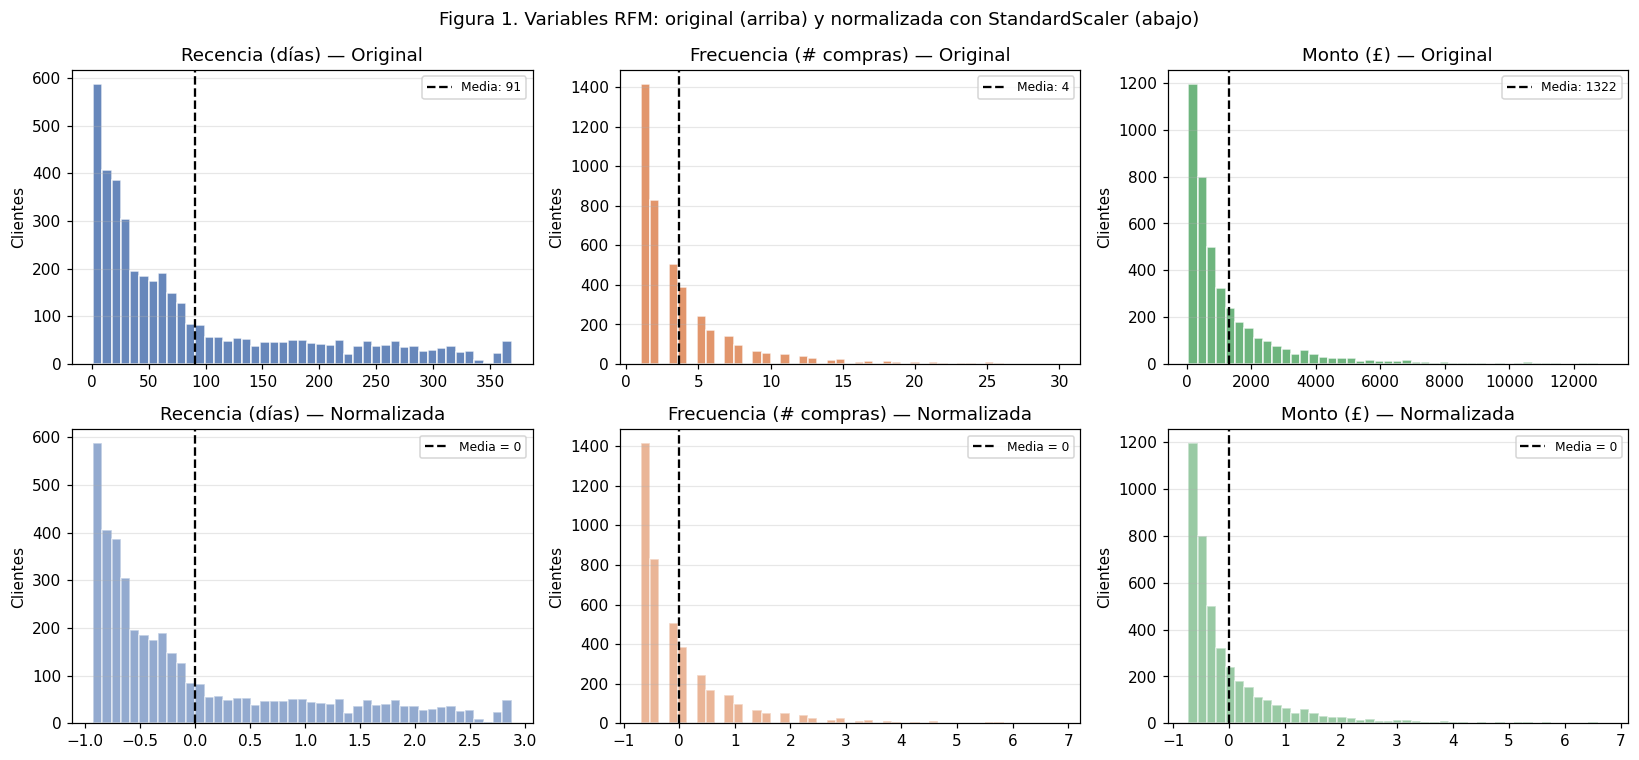

In [3]:
# Figura 1: distribuciones RFM antes y después de normalizar
vars_orig = ['recencia', 'frecuencia', 'monto']
vars_norm = ['recencia_norm', 'frecuencia_norm', 'monto_norm']
titulos = ['Recencia (días)', 'Frecuencia (# compras)', 'Monto (£)']

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
fig.suptitle('Figura 1. Variables RFM: original (arriba) y normalizada con StandardScaler (abajo)',
             fontsize=12)

for i, (col, col_n, tit) in enumerate(zip(vars_orig, vars_norm, titulos)):
    axes[0, i].hist(rfm_limpio[col], bins=45, color=COLORES[i], edgecolor='white', alpha=0.85)
    media = rfm_limpio[col].mean()
    axes[0, i].axvline(media, color='black', lw=1.5, ls='--', label=f'Media: {media:.0f}')
    axes[0, i].set_title(f'{tit} — Original')
    axes[0, i].set_ylabel('Clientes')
    axes[0, i].legend(fontsize=8)
    axes[0, i].grid(axis='y', alpha=0.3)

    axes[1, i].hist(rfm_normalizado[col_n], bins=45, color=COLORES[i], edgecolor='white', alpha=0.6)
    axes[1, i].axvline(0, color='black', lw=1.5, ls='--', label='Media = 0')
    axes[1, i].set_title(f'{tit} — Normalizada')
    axes[1, i].set_ylabel('Clientes')
    axes[1, i].legend(fontsize=8)
    axes[1, i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('variables_rfm_vs_standard_scaler.png', dpi=300)

plt.show()

**Observaciones:** La fila inferior muestra cómo después de la normalización todas las variables quedan centradas en cero y con la misma desviación estándar (σ = 1), lo que hace válida la comparación de distancias entre ellas. Los rangos no son idénticos porque StandardScaler no elimina los valores extremos, solo los reescala: si una variable tenía outliers muy lejanos, seguirán apareciendo lejos del centro, ahora expresados en unidades de desviación estándar en lugar de en su unidad original.

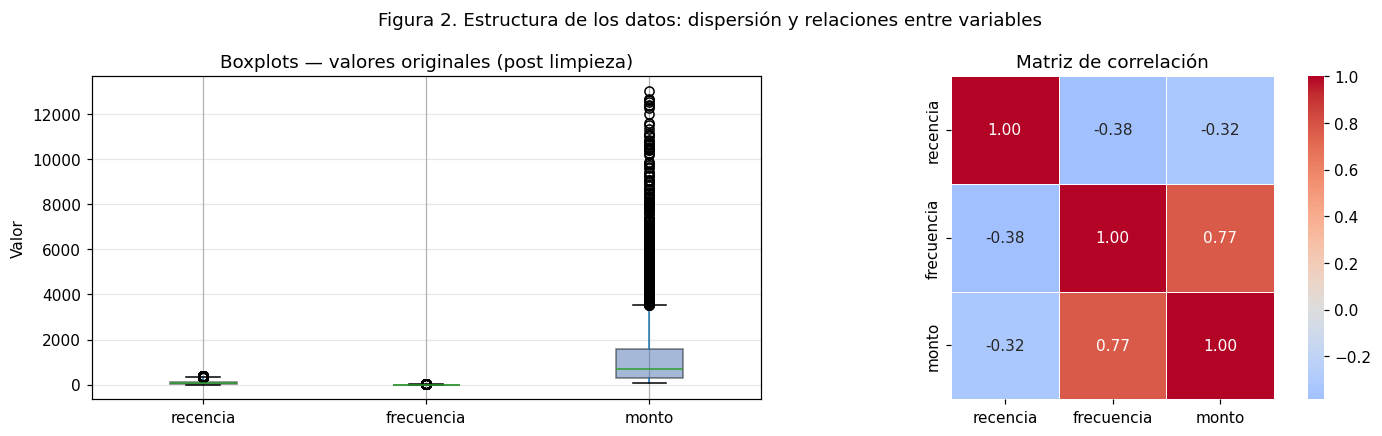

In [4]:
# Figura 2: boxplots + matriz de correlación
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Figura 2. Estructura de los datos: dispersión y relaciones entre variables', fontsize=12)

rfm_limpio[vars_orig].boxplot(ax=ax1, patch_artist=True,
    boxprops=dict(facecolor='#4C72B0', alpha=0.5))
ax1.set_title('Boxplots — valores originales (post limpieza)')
ax1.set_ylabel('Valor')
ax1.grid(axis='y', alpha=0.3)

corr = rfm_limpio[vars_orig].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax2)
ax2.set_title('Matriz de correlación')

plt.tight_layout()
plt.savefig('relacion_variables.png', dpi=300)

plt.show()

**Observaciones:** Los boxplots muestran que incluso después del recorte de outliers, la variable Monto sigue presentando valores atípicos considerables (los puntos por encima del bigote superior), lo que refuerza la necesidad de normalizar antes de medir distancias.
La matriz de correlación de nos dice que Frecuencia y Monto tienen una correlación positiva alta (0.77): quien compra más veces también tiende a gastar más en total. Recencia, en cambio, muestra una correlación negativa moderada con las otras dos variables (−0.38 con Frecuencia, −0.32 con Monto): los clientes que llevan más tiempo sin comprar tienden a tener menos compras acumuladas y menor gasto histórico, aunque la relación no es determinante.
Que ninguna correlación sea perfecta (±1.0) confirma que las tres variables aportan información complementaria al modelo, lo cual es deseable en clustering.

---
## 3. Exploración estructural con Clustering Jerárquico

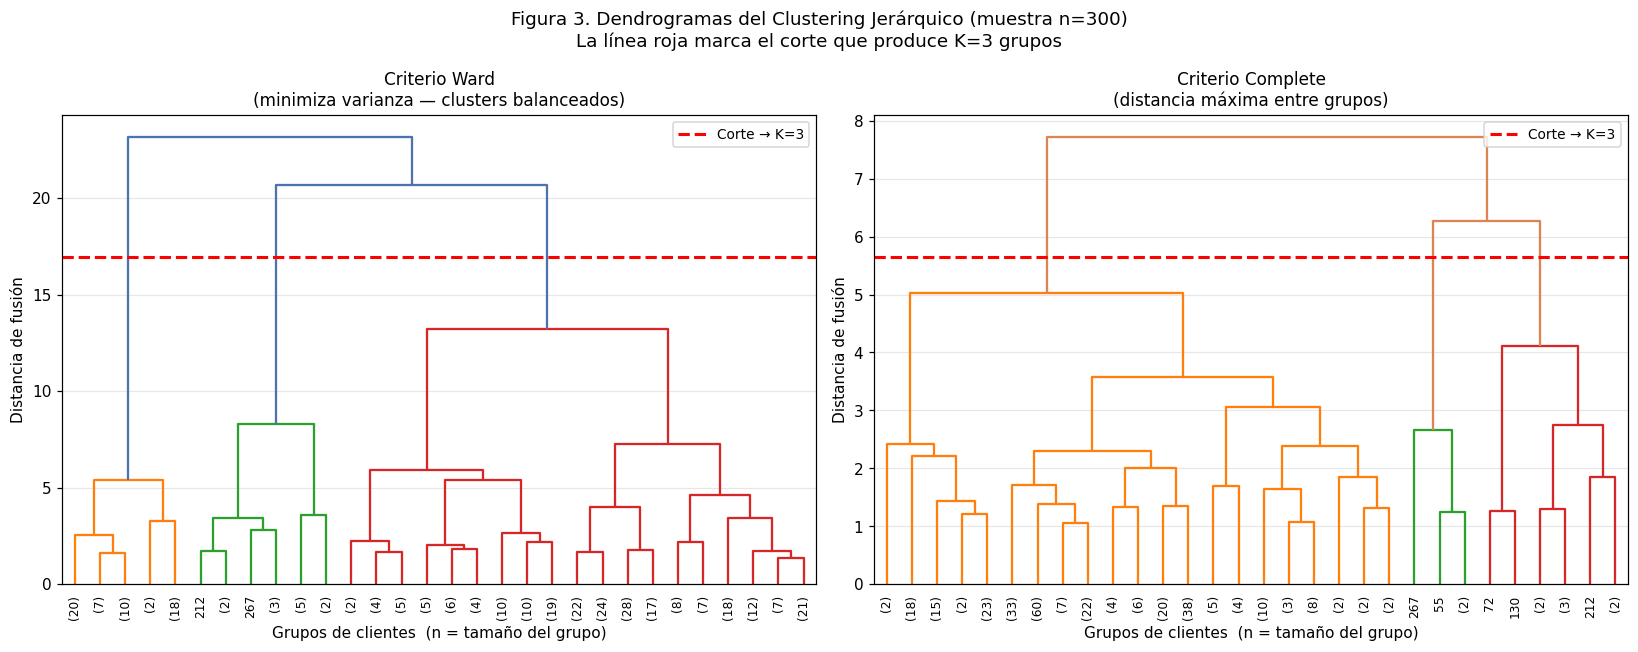

In [5]:
# Figura 3: dendrogramas Ward y Complete
np.random.seed(42)
idx_m = np.random.choice(len(X), size=300, replace=False)
X_m = X[idx_m]
K = 3

e_ward     = linkage(X_m, method='ward')
e_complete = linkage(X_m, method='complete')

def corte_para_k(enlace, k):
    alt = np.sort(enlace[:, 2])
    return (alt[-k] + alt[-(k-1)]) / 2

c_ward     = corte_para_k(e_ward, K)
c_complete = corte_para_k(e_complete, K)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Figura 3. Dendrogramas del Clustering Jerárquico (muestra n=300)\n'
             'La línea roja marca el corte que produce K=3 grupos', fontsize=12)

configs = [
    (ax1, e_ward,     c_ward,     'Criterio Ward\n(minimiza varianza — clusters balanceados)',  '#4C72B0'),
    (ax2, e_complete, c_complete, 'Criterio Complete\n(distancia máxima entre grupos)',          '#DD8452'),
]
for ax, enlace, corte, titulo, color in configs:
    dendrogram(enlace, truncate_mode='lastp', p=30,
               leaf_rotation=90, leaf_font_size=8,
               color_threshold=corte, above_threshold_color=color, ax=ax)
    ax.axhline(y=corte, color='red', ls='--', lw=2, label=f'Corte → K={K}')
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel('Grupos de clientes  (n = tamaño del grupo)')
    ax.set_ylabel('Distancia de fusión')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('dendrogramas_clustering_jerarquico.png', dpi=300)
plt.show()

**Observaciones:** En ambos dendrogramas la línea roja corta el árbol justo antes de los saltos de mayor altura, dejando tres ramas independientes. Esto indica que los tres grupos son internamente compactos y externamente distintos entre sí. En Ward, el salto antes del corte es muy pronunciado (de ~13 a más de 17 unidades), lo que da alta confianza en K=3. Sin embargo, los grupos resultantes no son necesariamente iguales en tamaño: Ward minimiza la varianza interna de cada cluster, no el número de clientes en cada uno. En Complete, el salto antes del corte existe pero es menos dramático, y la estructura del árbol es más ramificada y compleja, lo que refleja su sensibilidad a las distancias máximas entre puntos extremos de cada grupo.
En ambos casos K=3 es la lectura natural del dendrograma, lo que refuerza esta elección.

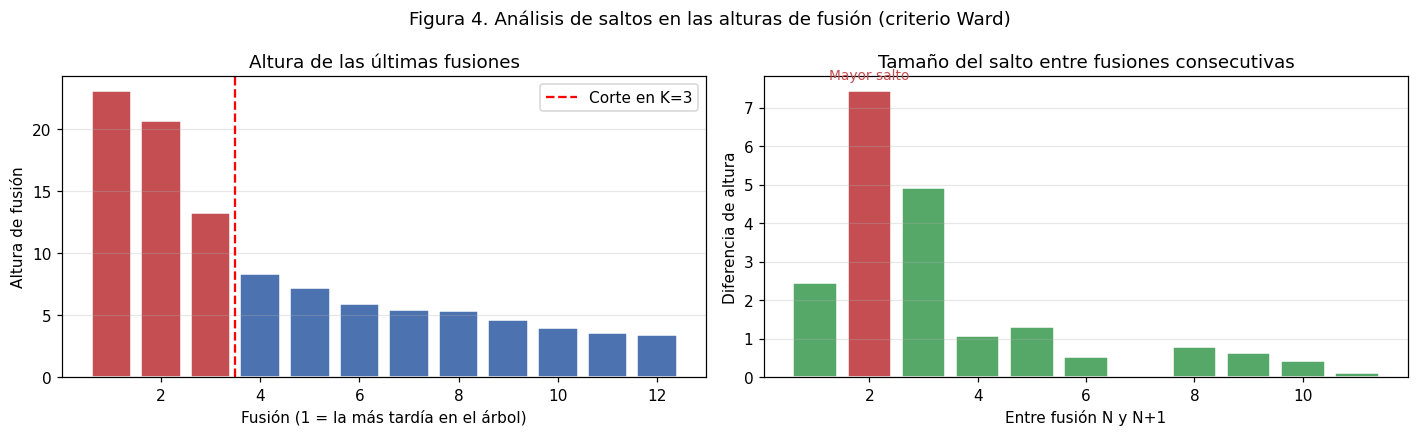

El mayor salto ocurre antes de la fusión 2 - K=3 es el corte natural.


In [6]:
# ── Figura 4: análisis de saltos de altura (Ward) ──
alt_desc = np.sort(e_ward[:, 2])[::-1][:12]
saltos = np.abs(np.diff(alt_desc))
idx_max = np.argmax(saltos)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Figura 4. Análisis de saltos en las alturas de fusión (criterio Ward)', fontsize=12)

cols1 = ['#C44E52' if i < K else '#4C72B0' for i in range(len(alt_desc))]
ax1.bar(range(1, len(alt_desc)+1), alt_desc, color=cols1, edgecolor='white')
ax1.axvline(K + 0.5, color='red', ls='--', lw=1.5, label=f'Corte en K={K}')
ax1.set_title('Altura de las últimas fusiones')
ax1.set_xlabel('Fusión (1 = la más tardía en el árbol)')
ax1.set_ylabel('Altura de fusión')
ax1.legend(); ax1.grid(axis='y', alpha=0.3)

cols2 = ['#C44E52' if i == idx_max else '#55A868' for i in range(len(saltos))]
ax2.bar(range(1, len(saltos)+1), saltos, color=cols2, edgecolor='white')
ax2.text(idx_max+1, saltos[idx_max]*1.04, 'Mayor salto', ha='center', fontsize=9, color='#C44E52')
ax2.set_title('Tamaño del salto entre fusiones consecutivas')
ax2.set_xlabel('Entre fusión N y N+1')
ax2.set_ylabel('Diferencia de altura')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('ward_saltos.png', dpi=300)
plt.show()
print(f'El mayor salto ocurre antes de la fusión {idx_max+1} - K={K} es el corte natural.')

**Observaciones:** La gráfica de la derecha muestra el tamaño del salto entre fusiones consecutivas. El mayor salto (en rojo, ≈7.3 unidades) ocurre entre la fusión 2 y la fusión 3, es decir, en el momento en que el algoritmo intentaría unir los dos grandes grupos que ya existen para colapsar todo en un solo cluster. Esa fusión es la más costosa de todo el árbol, lo que confirma cuantitativamente que K=3 es el punto de corte más natural: pasar de 3 a 2 grupos requeriría cruzar la mayor brecha de distancia de todo el proceso de agrupamiento.

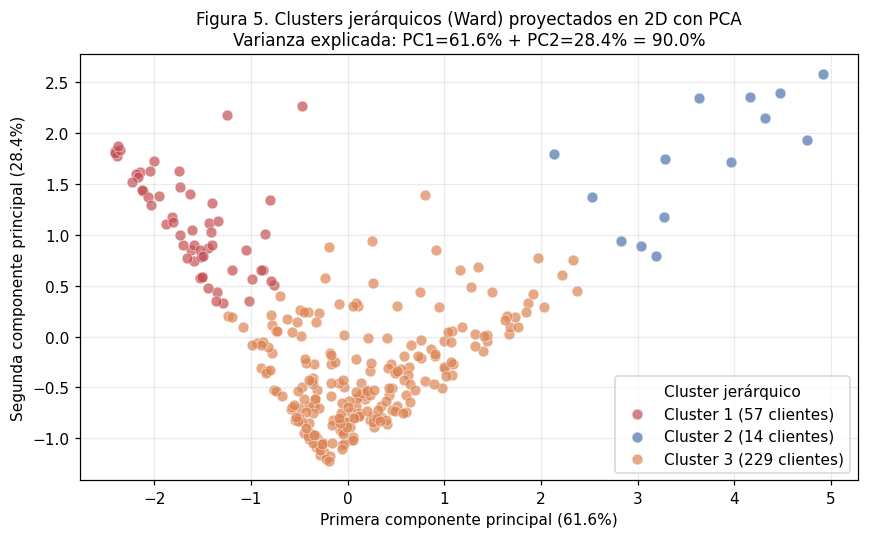

In [7]:
# Figura 5: scatter 2D de los clusters jerárquicos con PCA
etiq_jer = fcluster(e_ward, t=K, criterion='maxclust')
pca_j    = PCA(n_components=2, random_state=42)
coords_j = pca_j.fit_transform(X_m)
var_j    = pca_j.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(8, 5))
for i, c in enumerate(sorted(set(etiq_jer))):
    mask = etiq_jer == c
    ax.scatter(coords_j[mask, 0], coords_j[mask, 1],
               color=COLORES[i-1], alpha=0.7, s=50, edgecolors='white', lw=0.4,
               label=f'Cluster {c} ({mask.sum()} clientes)')

ax.set_title(f'Figura 5. Clusters jerárquicos (Ward) proyectados en 2D con PCA\n'
             f'Varianza explicada: PC1={var_j[0]*100:.1f}% + PC2={var_j[1]*100:.1f}% = {sum(var_j)*100:.1f}%',
             fontsize=11)
ax.set_xlabel(f'Primera componente principal ({var_j[0]*100:.1f}%)')
ax.set_ylabel(f'Segunda componente principal ({var_j[1]*100:.1f}%)')
ax.legend(title='Cluster jerárquico')
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('ward_clusters.png', dpi=300)
plt.show()

**Observaciones:** Como los datos RFM tienen tres dimensiones, se aplicó Análisis de Componentes Principales (PCA) para proyectarlos en dos dimensiones. La figura muestra una separación bastante clara entre los tres clusters. El Cluster 2 (azul, 14 clientes) está completamente aislado en la zona derecha, sin solapamiento con los demás. El Cluster 1 (rosa, 57 clientes) se concentra en la zona izquierda superior con algún solapamiento puntual con el Cluster 3 (naranja, 229 clientes), que es el grupo más numeroso y ocupa la zona central e inferior del espacio.
La distribución de tamaños es desbalanceada (229 / 57 / 14).

---
## 4. Segmentación con K-Medias

Se usó la inicialización **k-means++**, que en lugar de elegir los centroides iniciales al azar los distribuye de forma inteligente para evitar soluciones malas.

### Selección del K óptimo

Con el indicio de K=3 del clustering jerárquico, se confirmó esta elección con dos criterios cuantitativos:

- **Método del codo**: se grafica la inercia para K=2 hasta K=10. La curva baja rápido al principio y luego se aplana. El codo es el punto donde agregar más clusters ya no reduce la inercia de forma significativa.
- **Coeficiente de silueta**: para cada punto mide qué tan similar es a su propio cluster comparado con el cluster vecino más cercano. El rango va de -1 (mal asignado) a +1 (bien asignado). Se elige el K que maximiza este coeficiente promedio.

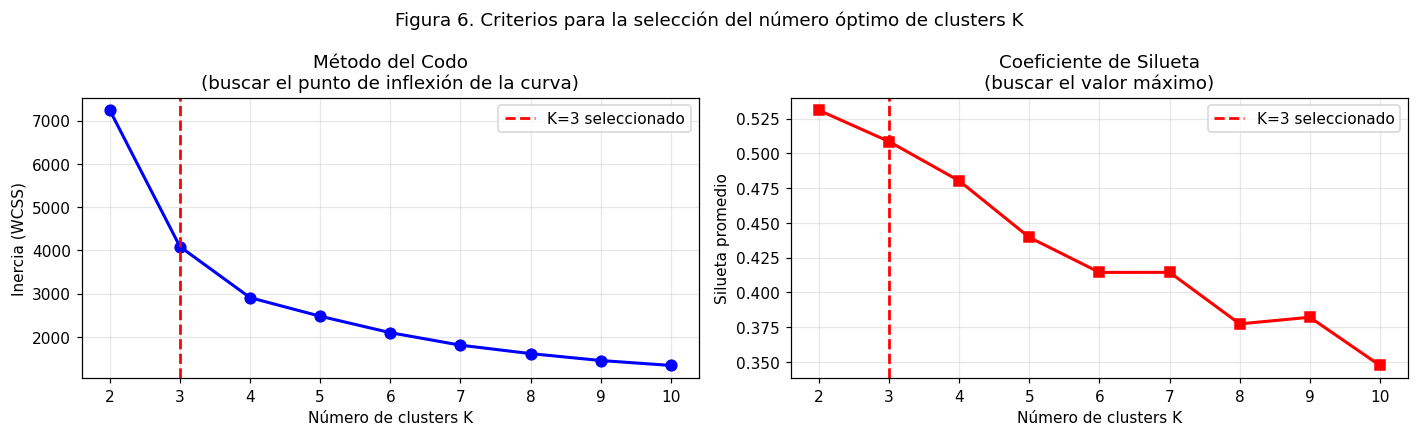

K=3 Inercia = 4086.6 | Coeficiente de silueta = 0.5085


In [8]:
# Figura 6: método del codo y coeficiente de silueta
rango_k  = range(2, 11)
inercias, siluetas = [], []
for k in rango_k:
    km  = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    lbl = km.fit_predict(X)
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(X, lbl))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Figura 6. Criterios para la selección del número óptimo de clusters K', fontsize=12)

ax1.plot(rango_k, inercias, 'bo-', lw=2, ms=7)
ax1.axvline(K, color='red', ls='--', lw=1.8, label=f'K={K} seleccionado')
ax1.set_title('Método del Codo\n(buscar el punto de inflexión de la curva)')
ax1.set_xlabel('Número de clusters K')
ax1.set_ylabel('Inercia (WCSS)')
ax1.set_xticks(list(rango_k)); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(rango_k, siluetas, 'rs-', lw=2, ms=7)
ax2.axvline(K, color='red', ls='--', lw=1.8, label=f'K={K} seleccionado')
ax2.set_title('Coeficiente de Silueta\n(buscar el valor máximo)')
ax2.set_xlabel('Número de clusters K')
ax2.set_ylabel('Silueta promedio')
ax2.set_xticks(list(rango_k)); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('seleccion_num_clusters.png', dpi=300)
plt.show()
print(f'K={K} Inercia = {inercias[K-2]:.1f} | Coeficiente de silueta = {siluetas[K-2]:.4f}')

**Observaciones:** La curva del codo muestra la reducción más pronunciada al pasar de K=2 a K=3 (de ≈7100 a ≈4000 de inercia). A partir de K=3 la curva continúa bajando pero de forma más gradual, y el aplanamiento más claro se observa a partir de K=6. Esto sugiere que K=3 marca el primer punto donde el beneficio de agregar un cluster empieza a disminuir significativamente.
El coeficiente de silueta muestra que el valor más alto corresponde a K=2 (≈0.53), seguido de K=3 (0.5085). K=2 se descarta no porque tenga peor silueta, sino porque dos segmentos resultan insuficientes y porque el análisis jerárquico evidenció tres grupos estructuralmente distintos. K=3 es así la elección que mejor equilibra la separación estadística de los clusters con su utilidad práctica para el negocio. Un coeficiente de silueta de 0.51 se considera bueno para datos de comportamiento del consumidor.

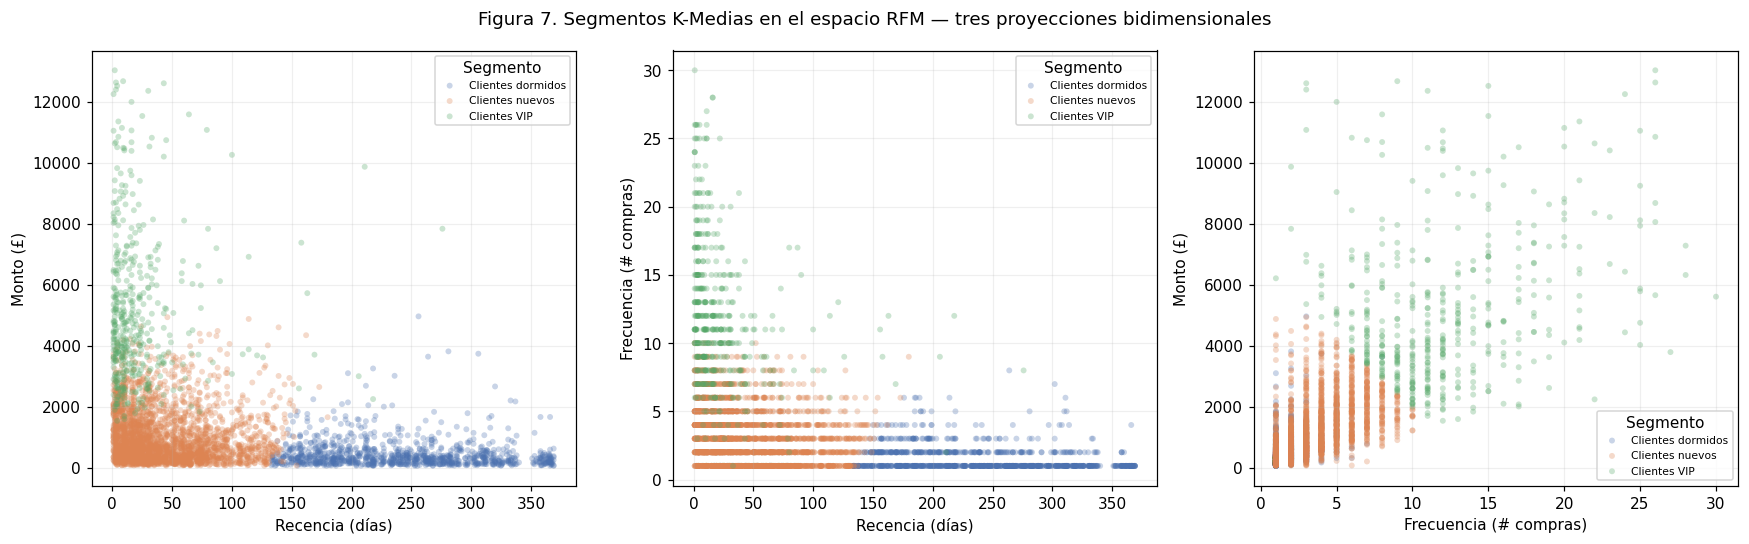

In [9]:
# Figura 7: scatter plots de los segmentos K-Medias (tres vistas RFM)
pares = [
    ('recencia',   'monto',      'Recencia (días)',        'Monto (£)'),
    ('recencia',   'frecuencia', 'Recencia (días)',        'Frecuencia (# compras)'),
    ('frecuencia', 'monto',      'Frecuencia (# compras)', 'Monto (£)'),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Figura 7. Segmentos K-Medias en el espacio RFM — tres proyecciones bidimensionales',
             fontsize=12)

for ax, (cx, cy, lx, ly) in zip(axes, pares):
    for i, cid in enumerate(sorted(NOMBRES)):
        mask = rfm_segmentado['cluster'] == cid
        ax.scatter(rfm_limpio.loc[mask, cx], rfm_limpio.loc[mask, cy],
                   color=COLORES[i], alpha=0.3, s=15, edgecolors='none',
                   label=f'{NOMBRES[cid]}')
    ax.set_xlabel(lx); ax.set_ylabel(ly)
    ax.legend(fontsize=7, title='Segmento')
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('segmentos_kmedidas_rfm.png', dpi=300)
plt.show()

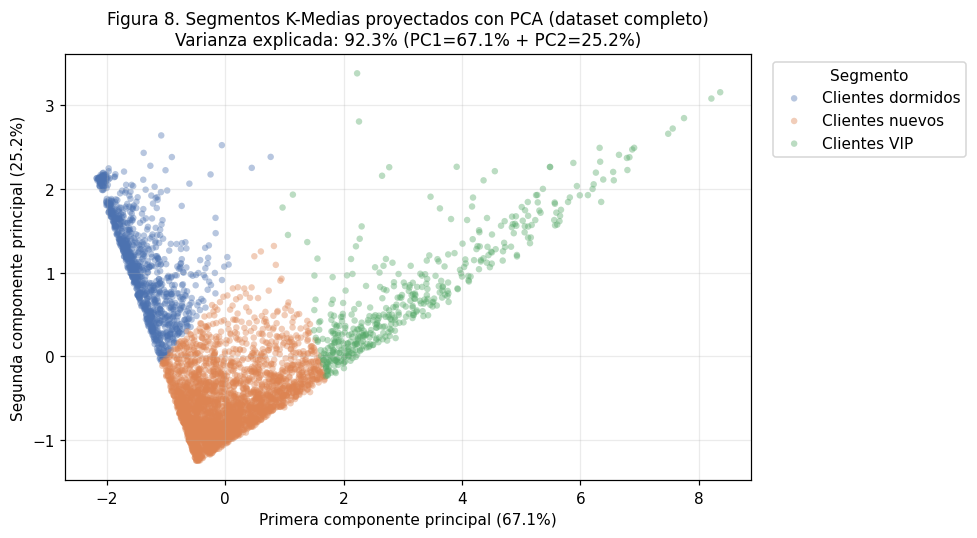

In [10]:
# Figura 8: segmentos K-Medias con PCA
pca     = PCA(n_components=2, random_state=42)
coords  = pca.fit_transform(X)
var_exp = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(9, 5))
for i, cid in enumerate(sorted(NOMBRES)):
    mask = (rfm_segmentado['cluster'] == cid).values
    ax.scatter(coords[mask, 0], coords[mask, 1],
               color=COLORES[i], alpha=0.4, s=18, edgecolors='none',
               label=f'{NOMBRES[cid]}')

ax.set_title(f'Figura 8. Segmentos K-Medias proyectados con PCA (dataset completo)\n'
             f'Varianza explicada: {sum(var_exp)*100:.1f}% '
             f'(PC1={var_exp[0]*100:.1f}% + PC2={var_exp[1]*100:.1f}%)', fontsize=11)
ax.set_xlabel(f'Primera componente principal ({var_exp[0]*100:.1f}%)')
ax.set_ylabel(f'Segunda componente principal ({var_exp[1]*100:.1f}%)')
ax.legend(title='Segmento', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('segmentos_kmedidas_pca.png', dpi=300)

plt.show()

**Observaciones**: La Figura 7 muestra los tres segmentos desde tres proyecciones del espacio RFM. En la vista Recencia vs. Monto, los Clientes VIP (verde) se distinguen principalmente por su recencia baja (compraron recientemente) aunque no concentran necesariamente los montos más extremos. Los puntos con mayor monto están distribuidos entre los tres segmentos. En la vista Recencia vs. Frecuencia, los Clientes VIP aparecen en la esquina superior izquierda (baja recencia, alta frecuencia), mientras que los Clientes dormidos (azul) se extienden hacia la derecha con recencia alta y frecuencia baja. La tercera vista (Frecuencia vs. Monto) refuerza que VIP y dormidos se diferencian claramente en ambas dimensiones.
La Figura 8 proyecta el dataset completo a 2D con PCA, conservando el 92.3% de la varianza original. La separación entre los tres segmentos es clara: Clientes VIP (verde) se extienden hacia la derecha a lo largo de PC1, Clientes dormidos (azul) ocupan la zona izquierda superior, y Clientes nuevos (naranja) se concentran en la zona central inferior. El solapamiento es principalmente entre Clientes dormidos y Clientes nuevos en la frontera central, lo cual es consistente con el coeficiente de silueta de 0.51 obtenido.
Recordemos que el modelo K-Medias produjo 3 segmentos para este dataset: Clientes VIP, Clientes nuevos y Clientes dormidos.

## 5. Caracterización de los segmentos

Una vez definidos los grupos, la tarea más importante es **entender qué cliente representa cada uno**. Los números solos no bastan: hay que traducirlos a un lenguaje de negocio que tenga sentido.

In [11]:
# Tabla 1: perfil estadístico por segmento
perfil = rfm_segmentado.groupby('cluster').agg(
    Segmento  = ('segmento',   'first'),
    Clientes  = ('segmento',   'count'),
    Rec_media = ('recencia',   'mean'),
    Rec_med   = ('recencia',   'median'),
    Frec_media= ('frecuencia', 'mean'),
    Frec_med  = ('frecuencia', 'median'),
    Monto_med = ('monto',      'mean'),
    Monto_mdn = ('monto',      'median'),
).round(1)
perfil['% total'] = (perfil['Clientes'] / perfil['Clientes'].sum() * 100).round(1)
perfil.columns = ['Segmento','Clientes','Rec.media','Rec.mediana',
                  'Frec.media','Frec.mediana','Monto medio £','Monto mediana £','% total']
print('Tabla 1. Perfil estadístico completo por segmento (valores originales no normalizados)')
print(perfil.to_string())

Tabla 1. Perfil estadístico completo por segmento (valores originales no normalizados)
                  Segmento  Clientes  Rec.media  Rec.mediana  Frec.media  Frec.mediana  Monto medio £  Monto mediana £  % total
cluster                                                                                                                        
0        Clientes dormidos      1024      241.0        239.0         1.5           1.0          448.1            311.4     24.6
1          Clientes nuevos      2696       45.3         36.0         3.1           3.0         1014.2            739.1     64.7
2             Clientes VIP       449       22.0         12.0        12.1          11.0         5163.6           4521.5     10.8


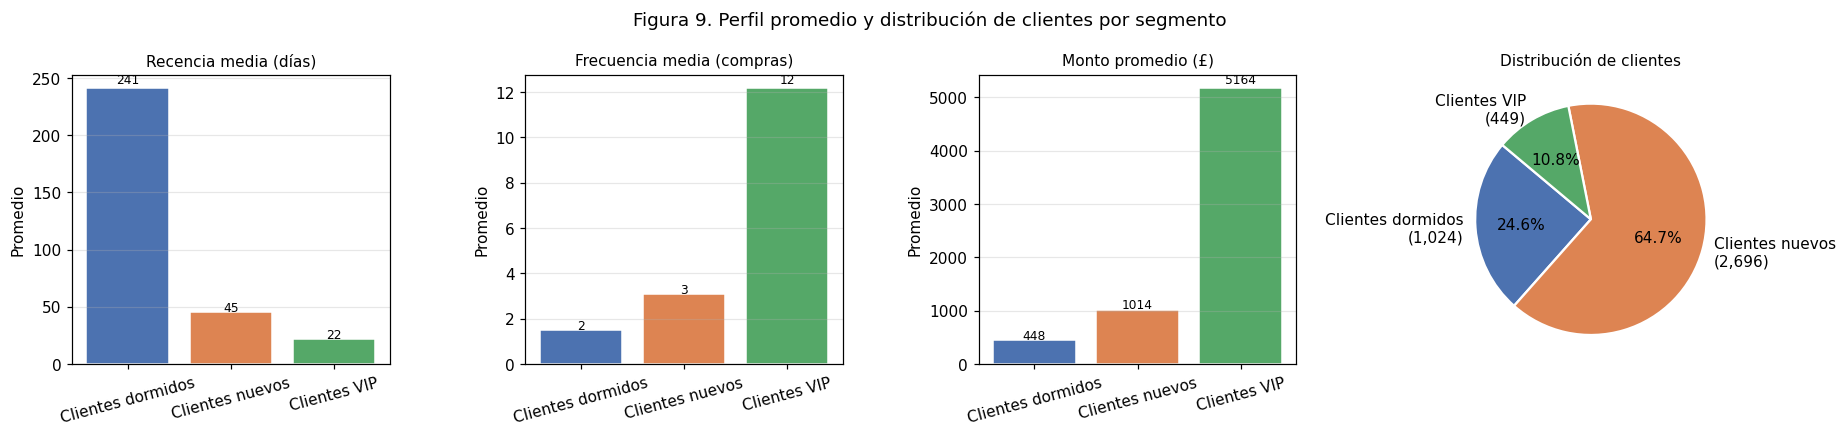

In [12]:
# Figura 9: perfil por variable + distribución de tamaño
vars_b    = ['recencia', 'frecuencia', 'monto']
titulos_b = ['Recencia media (días)', 'Frecuencia media (compras)', 'Monto promedio (£)']
nombres_s = [NOMBRES[c] for c in sorted(NOMBRES)]

fig, axes = plt.subplots(1, 4, figsize=(17, 4))
fig.suptitle('Figura 9. Perfil promedio y distribución de clientes por segmento', fontsize=12)

for i, (var, tit) in enumerate(zip(vars_b, titulos_b)):
    vals = [rfm_segmentado[rfm_segmentado['cluster']==c][var].mean() for c in sorted(NOMBRES)]
    bs   = axes[i].bar(nombres_s, vals, color=COLORES[:len(NOMBRES)], edgecolor='white')
    axes[i].set_title(tit, fontsize=10)
    axes[i].set_ylabel('Promedio')
    axes[i].tick_params(axis='x', rotation=15)
    axes[i].grid(axis='y', alpha=0.3)
    for b, v in zip(bs, vals):
        axes[i].text(b.get_x()+b.get_width()/2, v*1.02, f'{v:.0f}', ha='center', fontsize=8)

conteo = [rfm_segmentado[rfm_segmentado['cluster']==c].shape[0] for c in sorted(NOMBRES)]
etq_p  = [f'{NOMBRES[c]}\n({conteo[i]:,})' for i, c in enumerate(sorted(NOMBRES))]
axes[3].pie(conteo, labels=etq_p, colors=COLORES[:len(NOMBRES)],
            autopct='%1.1f%%', startangle=140,
            wedgeprops=dict(edgecolor='white', lw=1.5))
axes[3].set_title('Distribución de clientes', fontsize=10)

plt.tight_layout()
plt.savefig('distribucion_clientes_segmento.png', dpi=300)

plt.show()

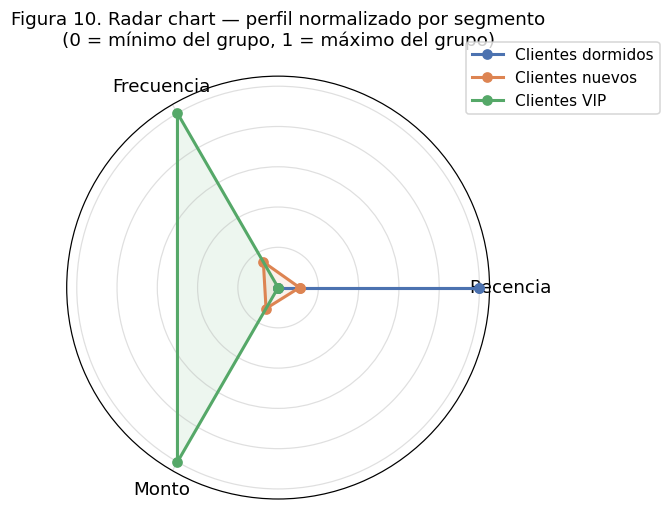

In [13]:
# Figura 10: radar chart (gráfica de araña)
perfil_rfm = rfm_segmentado.groupby('cluster')[['recencia','frecuencia','monto']].mean()
perfil_n   = perfil_rfm.copy()
for col in perfil_n.columns:
    r = perfil_n[col].max() - perfil_n[col].min()
    perfil_n[col] = (perfil_n[col] - perfil_n[col].min()) / r if r > 0 else 0

etiq_r  = ['Recencia', 'Frecuencia', 'Monto']
angulos = np.linspace(0, 2*np.pi, 3, endpoint=False).tolist() + [0]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
for i, cid in enumerate(sorted(NOMBRES)):
    vals = perfil_n.loc[cid].tolist() + [perfil_n.loc[cid, 'recencia']]
    ax.plot(angulos, vals, 'o-', lw=2, color=COLORES[i],
            label=f'{NOMBRES[cid]}')
    ax.fill(angulos, vals, alpha=0.1, color=COLORES[i])

ax.set_xticks(angulos[:-1])
ax.set_xticklabels(etiq_r, fontsize=12)
ax.set_yticklabels([])
ax.set_title('Figura 10. Radar chart — perfil normalizado por segmento\n'
             '(0 = mínimo del grupo, 1 = máximo del grupo)', fontsize=12, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.42, 1.1), fontsize=10)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('perfil_normalizado_segmento.png', dpi=300)

plt.show()

**Observaciones:** El radar chart o gráfica de araña revela perfiles muy distintos entre sí. Los Clientes VIP (verde) alcanzan el valor máximo en Frecuencia y Monto (≈1.0 en ambos ejes) y el mínimo en Recencia (cerca del centro), formando un polígono grande que se extiende hacia arriba y hacia abajo. Esto confirma su perfil: compran frecuentemente, gastan mucho y lo hicieron recientemente.
Los Clientes dormidos (azul) presentan el patrón opuesto: valor máximo en Recencia (se extienden hacia la derecha, llegando casi al borde) y valores mínimos en Frecuencia y Monto. Su polígono es una línea casi horizontal, lo que refleja que su único rasgo destacable es el tiempo transcurrido desde su última compra.
Es importante notar que en Recencia, más cerca del centro es mejor: un valor alto en ese eje significa más días sin comprar, no más actividad. Esta es la única variable RFM donde la interpretación del radar es inversa a las otras dos.
Los Clientes nuevos (naranja) tienen un polígono pequeño y comprimido cerca del centro en los tres ejes, lo que refleja valores intermedios-bajos en todo: compraron relativamente hace poco pero aún no han acumulado frecuencia ni monto significativos.

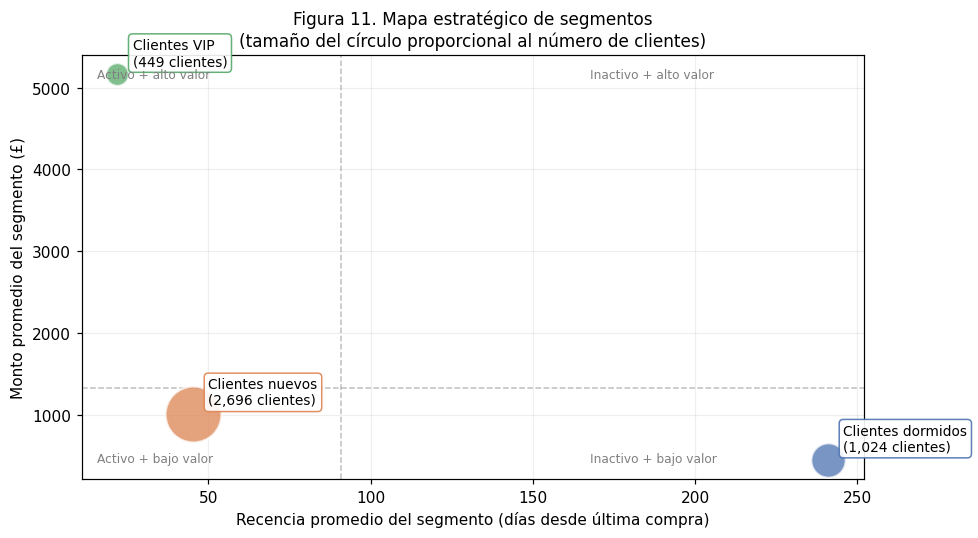

In [14]:
# Figura 11: Mapa de burbujas valor económico vs actividad reciente
fig, ax = plt.subplots(figsize=(9, 5))
for i, cid in enumerate(sorted(NOMBRES)):
    g = rfm_segmentado[rfm_segmentado['cluster'] == cid]
    r, m, n = g['recencia'].mean(), g['monto'].mean(), len(g)
    ax.scatter(r, m, s=n*0.5, color=COLORES[i], alpha=0.75, edgecolors='white', lw=1.5, zorder=3)
    ax.annotate(f"{NOMBRES[cid]}\n({n:,} clientes)",
                xy=(r, m), xytext=(10, 6), textcoords='offset points', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                          edgecolor=COLORES[i], alpha=0.9))

ax.axvline(rfm_segmentado['recencia'].mean(), color='gray', lw=1, ls='--', alpha=0.5)
ax.axhline(rfm_segmentado['monto'].mean(),    color='gray', lw=1, ls='--', alpha=0.5)
ax.text(0.02, 0.97, 'Activo + alto valor',   transform=ax.transAxes, fontsize=8, color='gray', va='top')
ax.text(0.65, 0.97, 'Inactivo + alto valor', transform=ax.transAxes, fontsize=8, color='gray', va='top')
ax.text(0.02, 0.04, 'Activo + bajo valor',   transform=ax.transAxes, fontsize=8, color='gray')
ax.text(0.65, 0.04, 'Inactivo + bajo valor', transform=ax.transAxes, fontsize=8, color='gray')
ax.set_xlabel('Recencia promedio del segmento (días desde última compra)')
ax.set_ylabel('Monto promedio del segmento (£)')
ax.set_title('Figura 11. Mapa estratégico de segmentos\n'
             '(tamaño del círculo proporcional al número de clientes)', fontsize=11)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('mapa_segmentos.png', dpi=300)
plt.show()

**Observaciones:** En el gráfico podemos observar las dos cosas más importantes desde el punto de vista del negocio: cuánto dinero aporta cada segmento (eje vertical) y qué tan activos están hoy (eje horizontal). Las líneas punteadas grises marcan el promedio global y dividen el espacio en cuatro zonas. El tamaño de cada círculo refleja cuántos clientes hay en ese grupo.
Lo primero que llama la atención es que el grupo más grande no es el más valioso: los Clientes nuevos son 2,696 — más de la mitad de toda la base — pero tienen el monto promedio más bajo. Los Clientes VIP son solo 449, pero su monto promedio supera los £5,000, ubicándolos en el cuadrante superior izquierdo: activos y de alto valor.

**Clientes VIP (449 clientes)**
Compraron hace muy poco (recencia ≈ 20 días), con frecuencia y gasto acumulado muy por encima del promedio. Son pocos pero generan una parte desproporcionada de los ingresos. Perder a uno de estos clientes tiene un impacto real en la facturación. Son la prioridad número uno de retención.

**Clientes nuevos (2,696 clientes)**
Compraron recientemente pero su gasto y frecuencia todavía son bajos. Son el grupo más grande de la base y representan la mayor oportunidad de crecimiento: están activos, lo que significa que la puerta está abierta. El momento más importante para convertirlos en clientes frecuentes son las semanas siguientes a su primera compra.

**Clientes dormidos (1,024 clientes)**
Llevan en promedio más de 240 días sin comprar y su historial es escaso. Están en la esquina inferior derecha: inactivos y de bajo valor. No todos vale la pena intentar recuperar el costo de una campaña puede superar fácilmente lo que se espera ganar. La mejor estrategia es identificar dentro de este grupo a los pocos que hicieron más de una compra antes de desaparecer, y enfocar el esfuerzo solo en ellos.

## 6. Clasificación automática de nuevos clientes con K-NN
### Decisiones de diseño del modelo

Se tomaron tres decisiones:

1. **División 80/20 con estratificación**: el 80% de los clientes se usó para entrenar y el 20% para evaluar.

2. **Selección del K óptimo con validación cruzada 5-fold**: en lugar de evaluar en un único subconjunto de prueba, la *validación cruzada* divide el conjunto de entrenamiento en 5 partes iguales, entrena en 4 y evalúa en 1, rotando la parte de evaluación. Esto produce una estimación más confiable del rendimiento real.

3. **Comparación de ponderación `uniform` vs `distance`**: en la versión uniforme todos los K vecinos tienen el mismo peso al votar. En la versión por distancia, los vecinos más cercanos pesan más. Ambas se probaron y se eligió la que produjo mayor accuracy en validación cruzada.

In [15]:
# ── Entrenamiento del clasificador K-NN ──
y = rfm_segmentado['cluster'].values

X_tr, X_ts, y_tr, y_ts = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

rango_v  = list(range(1, 20, 2))
scores_u = [cross_val_score(KNeighborsClassifier(n_neighbors=k, weights='uniform'),
                            X_tr, y_tr, cv=5).mean() for k in rango_v]
scores_d = [cross_val_score(KNeighborsClassifier(n_neighbors=k, weights='distance'),
                            X_tr, y_tr, cv=5).mean() for k in rango_v]

if max(scores_d) >= max(scores_u):
    K_KNN, POND = rango_v[scores_d.index(max(scores_d))], 'distance'
else:
    K_KNN, POND = rango_v[scores_u.index(max(scores_u))], 'uniform'

knn    = KNeighborsClassifier(n_neighbors=K_KNN, weights=POND, metric='euclidean')
knn.fit(X_tr, y_tr)
y_pred = knn.predict(X_ts)
ACC    = accuracy_score(y_ts, y_pred)

print(f'Configuración seleccionada:')
print(f'  K vecinos    : {K_KNN}')
print(f'  Ponderación  : {POND}')
print(f'  Accuracy     : {ACC:.4f}  ({ACC*100:.1f}%)')

Configuración seleccionada:
  K vecinos    : 11
  Ponderación  : distance
  Accuracy     : 0.9940  (99.4%)


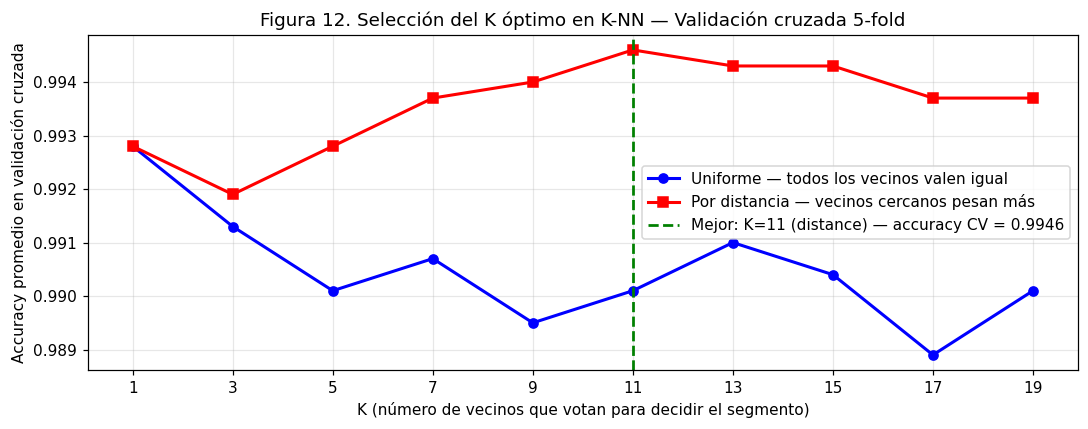

In [16]:
# Figura 12: curva de selección del K óptimo (validación cruzada 5-fold) ──
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(rango_v, scores_u, 'bo-', lw=2, ms=6, label='Uniforme — todos los vecinos valen igual')
ax.plot(rango_v, scores_d, 'rs-', lw=2, ms=6, label='Por distancia — vecinos cercanos pesan más')
mejor_acc = max(scores_d if POND == 'distance' else scores_u)
ax.axvline(K_KNN, color='green', ls='--', lw=1.8,
           label=f'Mejor: K={K_KNN} ({POND}) — accuracy CV = {mejor_acc:.4f}')
ax.set_title('Figura 12. Selección del K óptimo en K-NN — Validación cruzada 5-fold', fontsize=12)
ax.set_xlabel('K (número de vecinos que votan para decidir el segmento)')
ax.set_ylabel('Accuracy promedio en validación cruzada')
ax.set_xticks(rango_v); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('seleccion_k_optimo_vc.png', dpi=300)
plt.show()

**Observaciones:** La Figura 12 muestra cómo cambia el porcentaje de aciertos del modelo al variar el número de vecinos K, probando dos formas de votación: uniforme (todos los vecinos pesan igual, curva azul) y por distancia (los vecinos más cercanos tienen más influencia, curva roja).
Lo primero que llama la atención es que la ponderación por distancia es consistentemente mejor que la uniforme en casi todos los valores de K. Esto tiene sentido: si un cliente nuevo es muy parecido a un vecino cercano, tiene más lógica que ese vecino influya más en la decisión que uno que está lejos.
El mejor resultado se obtiene con K=11 y ponderación por distancia, alcanzando un accuracy de 0.9946 en validación cruzada, es decir, el modelo clasifica correctamente casi el 99.5% de los casos. Cabe destacar que todos los valores están entre 0.989 y 0.995, lo que indica que el modelo es bastante estable: no cambia dramáticamente con distintos valores de K.
En cuanto a K=1, aunque en teoría es el más propenso a memorizar los datos de entrenamiento en lugar de aprender patrones generales, en este caso no produce el mejor resultado de todas formas, por lo que la elección de K=11 está doblemente justificada: es más robusto y además logra el mayor accuracy.

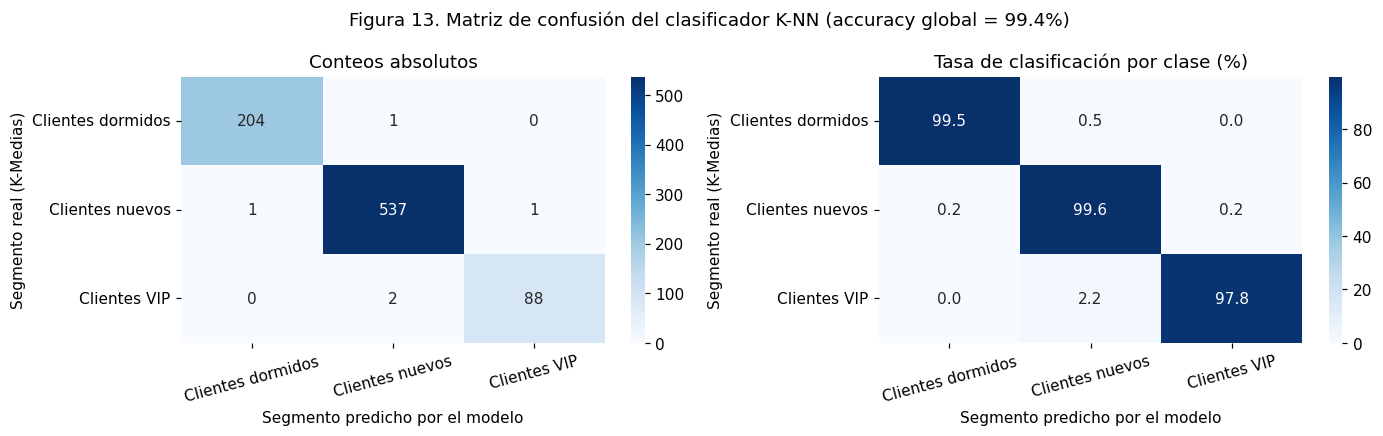

In [17]:
# Figura 13: doble matriz de confusión
nombres_cls = [NOMBRES[c] for c in sorted(np.unique(y))]
cm     = confusion_matrix(y_ts, y_pred, labels=sorted(np.unique(y)))
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f'Figura 13. Matriz de confusión del clasificador K-NN'
             f' (accuracy global = {ACC:.1%})', fontsize=12)

for ax, data, fmt, titulo in [
    (ax1, cm,     'd',   'Conteos absolutos'),
    (ax2, cm_pct, '.1f', 'Tasa de clasificación por clase (%)'),
]:
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=nombres_cls, yticklabels=nombres_cls, ax=ax)
    ax.set_title(titulo)
    ax.set_xlabel('Segmento predicho por el modelo')
    ax.set_ylabel('Segmento real (K-Medias)')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('matriz_confusion.png', dpi=300)
plt.show()

**Observaciones:**
La matriz de confusión muestra exactamente dónde acierta y dónde se equivoca el modelo. Cada fila representa lo que el cliente realmente es (según K-Medias), y cada columna lo que el modelo predijo. Los números en la diagonal son los aciertos; los que están fuera son los errores.
Los resultados son muy buenos en los tres segmentos:

Clientes dormidos: 204 de 205 clasificados correctamente (99.5%). Solo 1 fue confundido con Clientes nuevos.
Clientes nuevos: 537 de 539 correctos (99.6%). 1 fue clasificado como dormido y 1 como VIP.
Clientes VIP: 88 de 90 correctos (97.8%). Los 2 errores fueron clasificados como Clientes nuevos.

El patrón de errores tiene lógica: los únicos casos confundidos son VIP con Clientes nuevos. Ambos grupos comparten una característica — compraron recientemente — y lo que los diferencia es el historial acumulado de frecuencia y monto. Un cliente VIP que lleva poco tiempo en la tienda puede parecerse mucho a un cliente nuevo que hizo una compra grande, y ahí es donde el modelo duda.
Con un accuracy global de 99.4%, el clasificador es confiable para usarse en producción.

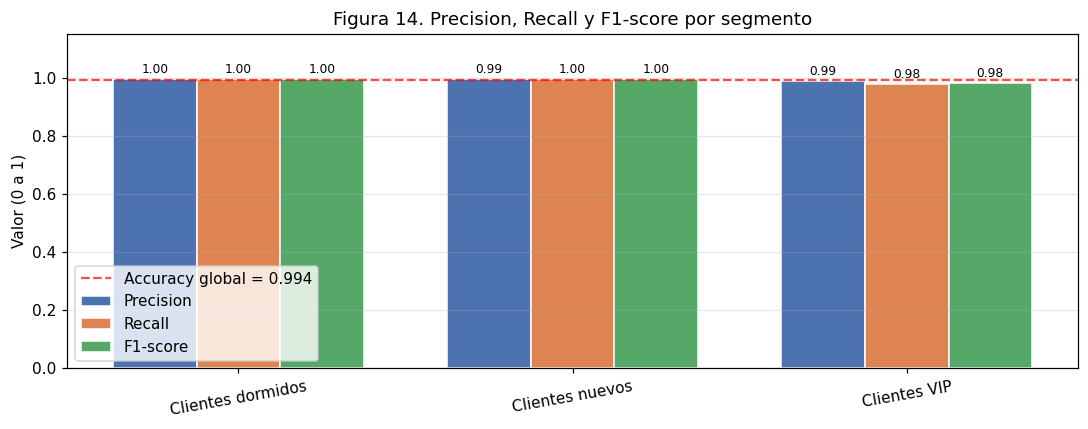


Reporte completo de clasificación:
                   precision    recall  f1-score   support

Clientes dormidos      0.995     0.995     0.995       205
  Clientes nuevos      0.994     0.996     0.995       539
     Clientes VIP      0.989     0.978     0.983        90

         accuracy                          0.994       834
        macro avg      0.993     0.990     0.991       834
     weighted avg      0.994     0.994     0.994       834



In [18]:
# ── Figura 14: Precision, Recall y F1 por segmento ──
prec, rec, f1, _ = precision_recall_fscore_support(
    y_ts, y_pred, labels=sorted(np.unique(y)))
x, aw = np.arange(len(nombres_cls)), 0.25

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - aw, prec, aw, label='Precision', color='#4C72B0', edgecolor='white')
ax.bar(x,      rec,  aw, label='Recall',    color='#DD8452', edgecolor='white')
ax.bar(x + aw, f1,   aw, label='F1-score',  color='#55A868', edgecolor='white')
ax.axhline(ACC, color='red', ls='--', alpha=0.7, label=f'Accuracy global = {ACC:.3f}')
ax.set_title('Figura 14. Precision, Recall y F1-score por segmento', fontsize=12)
ax.set_xticks(x); ax.set_xticklabels(nombres_cls, rotation=10)
ax.set_ylabel('Valor (0 a 1)'); ax.set_ylim(0, 1.15)
ax.legend(); ax.grid(axis='y', alpha=0.3)
for cont in ax.containers:
    ax.bar_label(cont, fmt='%.2f', fontsize=8, padding=2)
plt.tight_layout()
plt.savefig('reporte_completo.png', dpi=300)

plt.show()

print('\nReporte completo de clasificación:')
print(classification_report(y_ts, y_pred, target_names=nombres_cls, digits=3))

**Observaciones:** El accuracy global nos dice que el modelo acierta el 99.4% de las veces, pero no nos dice si falla más con un grupo que con otro. Para eso existen tres medidas específicas por segmento:

Precision: de todos los clientes que el modelo dijo que eran del segmento X, ¿cuántos realmente lo eran? Si es baja, el modelo está metiendo clientes en el segmento equivocado.
Recall: de todos los clientes que realmente son del segmento X, ¿cuántos detectó el modelo? Si es bajo, el modelo está dejando escapar clientes que debería haber capturado.
F1-score: combina las dos medidas anteriores en un solo número. Es útil cuando ambas importan por igual.

Los resultados por segmento son muy sólidos:
SegmentoPrecisionRecallF1Clientes dormidos99.5%99.5%99.5%Clientes nuevos99.4%99.6%99.5%Clientes VIP98.9%97.8%98.3%
El segmento con resultados ligeramente más bajos es Clientes VIP, precisamente donde más importa no equivocarse. Su Recall de 97.8% significa que de cada 100 clientes VIP reales, el modelo identifica correctamente a 98 y solo deja escapar 2. En términos de negocio eso es muy aceptable, pero refuerza la recomendación de revisar manualmente los casos clasificados como "Clientes nuevos" que tengan historial de compras inusualmente alto — podrían ser VIPs que el modelo no reconoció.

Tabla 2. Predicción de segmento para clientes nuevos
────────────────────────────────────────────────────────────────────
  Cliente A Activo y frecuente  R=10d, F=15x, M=£3,500
     Clientes VIP  (confianza: 100%)

  Cliente B Dormido             R=300d, F=2x, M=£150
     Clientes dormidos  (confianza: 100%)

  Cliente C En riesgo           R=180d, F=10x, M=£2,200
     Clientes nuevos  (confianza: 55%)

────────────────────────────────────────────────────────────────────


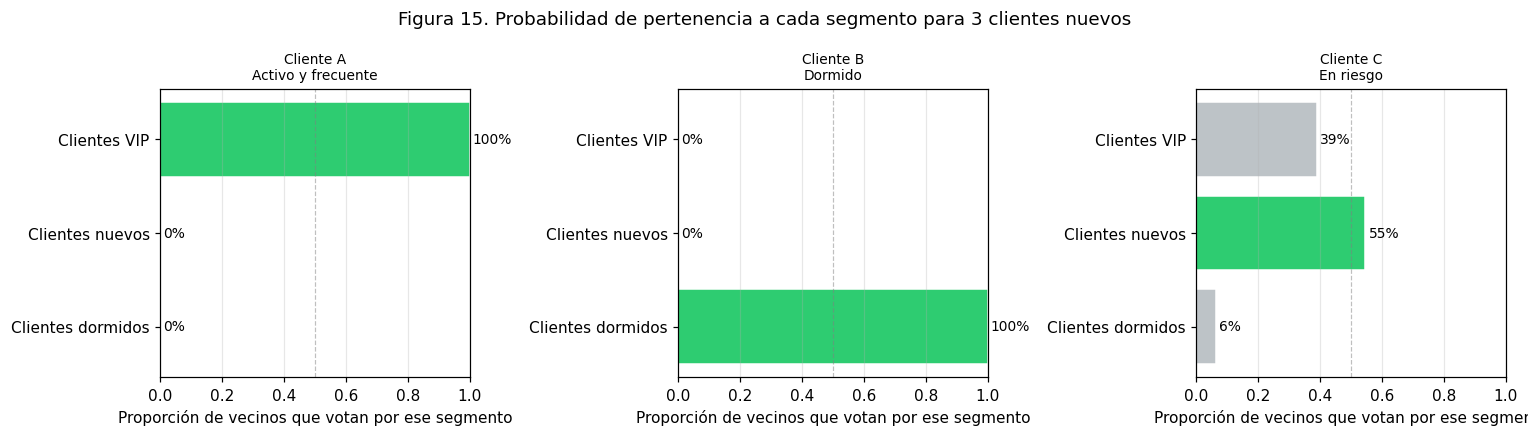

In [19]:
# Figura 15: predicción de 3 clientes nuevos simulados
scaler = StandardScaler()
scaler.fit(rfm_limpio[['recencia','frecuencia','monto']])

nuevos = [
    ('Cliente A\nActivo y frecuente',  10,  15, 3500),
    ('Cliente B\nDormido',            300,   2,  150),
    ('Cliente C\nEn riesgo',          180,  10, 2200),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Figura 15. Probabilidad de pertenencia a cada segmento para 3 clientes nuevos', fontsize=12)

print('Tabla 2. Predicción de segmento para clientes nuevos')
print(f'{"─"*68}')
for ax, (nombre, r, f, m) in zip(axes, nuevos):
    datos_n  = scaler.transform([[r, f, m]])
    cid_p    = knn.predict(datos_n)[0]
    probs    = knn.predict_proba(datos_n)[0]
    clases   = knn.classes_

    colores_b = ['#2ecc71' if c == cid_p else '#bdc3c7' for c in clases]
    etiq_b    = [NOMBRES.get(c, f'C{c}') for c in clases]
    ax.barh(etiq_b, probs, color=colores_b, edgecolor='white')
    ax.set_xlim(0, 1)
    ax.set_title(nombre, fontsize=9)
    ax.set_xlabel('Proporción de vecinos que votan por ese segmento')
    ax.axvline(0.5, color='gray', lw=0.8, ls='--', alpha=0.5)
    ax.grid(axis='x', alpha=0.3)
    for j, v in enumerate(probs):
        ax.text(v + 0.01, j, f'{v:.0%}', va='center', fontsize=9)

    print(f'  {nombre.replace(chr(10)," "):28}  R={r}d, F={f}x, M=£{m:,}')
    print(f'     {NOMBRES[cid_p]}  (confianza: {max(probs):.0%})')
    print()

print(f'{"─"*68}')
plt.tight_layout()
plt.savefig('p_pretenencia_clientes.png', dpi=300)

plt.show()

**Observaciones:** Cada gráfica muestra qué porcentaje de los 11 vecinos más cercanos de cada cliente nuevo pertenece a cada segmento. Ese porcentaje es la "confianza" del modelo: mientras más concentrada esté la barra en un solo segmento, más seguro está el modelo de su decisión.
Los tres casos muestran situaciones muy distintas:
Cliente A (compró hace 10 días, 15 compras, £3,500) → el 100% de sus vecinos son Clientes VIP. El modelo no tiene ninguna duda: este cliente tiene exactamente el perfil de un comprador frecuente y de alto valor.
Cliente B (compró hace 300 días, 2 compras, £150) → el 100% de sus vecinos son Clientes dormidos. También sin dudas: lleva casi un año sin comprar y su historial es mínimo.
Cliente C (compró hace 180 días, 10 compras, £2,200) → aquí el modelo duda: 55% de sus vecinos son Clientes nuevos, 39% son Clientes VIP y solo 6% dormidos. Este es el caso más interesante: tiene un historial considerable (10 compras, buen monto) pero lleva 6 meses sin comprar. El modelo lo clasifica como "nuevo" por mayoría, pero el 39% que vota por VIP sugiere que podría ser un cliente valioso que simplemente se alejó. Este tipo de caso merece revisión manual antes de decidir qué estrategia aplicar.
Un detalle técnico importante: para que las predicciones sean correctas, los datos de los clientes nuevos deben normalizarse con los mismos parámetros que se usaron al entrenar el modelo. Si se usaran parámetros distintos, sería como medir distancias en unidades diferentes — el modelo buscaría vecinos en el lugar equivocado.

## 7. Comparación de los tres métodos

Los tres algoritmos no compiten entre sí: cada uno resolvió una parte diferente del problema. Su uso en secuencia refleja una práctica metodológica deliberada.

In [20]:
# ── Tabla 3: comparación técnica y metodológica de los tres métodos ──
comp = pd.DataFrame({
    'Aspecto': [
        'Paradigma de aprendizaje',
        '¿Requiere definir K?',
        'Clientes procesados',
        'Complejidad computacional',
        'Forma de clusters asumida',
        'Resultado cuantitativo principal',
        'Rol en este proyecto'
    ],
    'Clustering Jerárquico': [
        'No supervisado',
        'No — K emerge del dendrograma',
        'Muestra de 300 (limitación O(n³))',
        'Alta — O(n³) en tiempo y O(n²) en memoria',
        'Flexible — cualquier forma',
        'Sugirió K = 3 por análisis de saltos',
        'Exploración inicial — definir K'
    ],
    'K-Medias': [
        'No supervisado',
        f'Sí — K=3 confirmado por codo + silueta',
        f'Todos ({len(rfm_segmentado):,} clientes)',
        'Baja — O(nKdI) lineal en el número de datos',
        'Esférica — grupos convexos',
        f'Silueta = {siluetas[K-2]:.4f}',
        'Segmentación definitiva — crear etiquetas'
    ],
    'K-NN': [
        'Supervisado (usa las etiquetas de K-Medias)',
        f'Sí — K={K_KNN} vecinos elegido por CV-5',
        f'80% entrena / 20% prueba',
        'Entrenamiento O(1), predicción O(nd)',
        'No aplica — es clasificador',
        f'Accuracy = {ACC:.1%} | F1 macro ≈ ver Figura 14',
        'Clasificación automática de clientes nuevos'
    ]
})
print('Tabla 3. Comparación técnica de los tres métodos aplicados')
print(comp.to_string(index=False))

Tabla 3. Comparación técnica de los tres métodos aplicados
                         Aspecto                     Clustering Jerárquico                                    K-Medias                                        K-NN
        Paradigma de aprendizaje                            No supervisado                              No supervisado Supervisado (usa las etiquetas de K-Medias)
            ¿Requiere definir K?             No — K emerge del dendrograma      Sí — K=3 confirmado por codo + silueta          Sí — K=11 vecinos elegido por CV-5
             Clientes procesados         Muestra de 300 (limitación O(n³))                      Todos (4,169 clientes)                    80% entrena / 20% prueba
       Complejidad computacional Alta — O(n³) en tiempo y O(n²) en memoria Baja — O(nKdI) lineal en el número de datos        Entrenamiento O(1), predicción O(nd)
       Forma de clusters asumida                Flexible — cualquier forma                  Esférica — grupos convexos        

**Observaciones:**

¿Por qué los tres métodos llegaron al mismo número de grupos?
Dos algoritmos que funcionan de maneras completamente distintas, uno construyendo un árbol de fusiones, el otro moviendo centroides hasta que todo encaja, encontraron de forma independiente que 3 es el número natural de grupos en estos datos. Eso no es casualidad.
Cuando dos caminos distintos llevan al mismo destino, hay buenas razones para confiar en ese destino. Los clientes de esta tienda se dividen en tres comportamientos lo suficientemente distintos como para que cualquier método serio los detecte. No son grupos que el analista inventó: están en los datos.

7.2 Cosas que este análisis no puede hacer (y está bien reconocerlo)
Todo modelo tiene límites. Estos son los más importantes a tener en cuenta:

K-Medias prefiere grupos redondos: el algoritmo funciona mejor cuando los grupos tienen formas compactas y similares. En este caso las visualizaciones sugieren que sí es así, pero en otros datasets podría no serlo.

El árbol jerárquico trabajó con solo 300 clientes: fue suficiente para explorar la estructura, y la coincidencia con K-Medias sobre los 4,169 clientes completos da confianza en que la muestra fue representativa.

K-NN guarda todos los datos para predecir: si la base crece a cientos de miles de clientes, las predicciones se volverán más lentas. En ese momento conviene evaluar algoritmos más ligeros.

Los segmentos cambian con el tiempo: un cliente VIP hoy puede volverse dormido en seis meses. Se recomienda repetir el análisis cada trimestre para mantener los grupos actualizados.

Con tres segmentos identificados, la pregunta práctica es: ¿cuál atendemos primero?

Los Clientes VIP son la prioridad más alta. Son solo 449 personas pero generan una parte desproporcionada de los ingresos. No requieren grandes descuentos — requieren atención: un programa de lealtad, acceso anticipado a productos, servicio diferenciado. Ignorarlos es el error más costoso que puede cometer el negocio.

Los Clientes nuevos son la mayor oportunidad de crecimiento. Son 2,696 personas que ya dieron el primer paso. Las semanas siguientes a su primera compra son el momento más valioso para construir el hábito: un descuento en la segunda compra o una recomendación personalizada pueden marcar la diferencia entre un cliente frecuente y uno que no vuelve.

Los Clientes dormidos requieren más cuidado antes de invertir. Son 1,024 personas que llevan en promedio más de 240 días sin comprar. No todos vale la pena intentar recuperar: la estrategia más inteligente es identificar dentro de este grupo a los que tuvieron más de una compra antes de desaparecer, y enfocar el esfuerzo solo en ellos.

## 8. Conclusiones
¿Qué logramos?
Partiendo de más de 500000 registros de transacciones, construimos un sistema completo que: limpia y organiza los datos, agrupa a los clientes en segmentos con comportamientos distintos, y clasifica automáticamente a cualquier cliente nuevo. Todo usando los tres algoritmos vistos en clase.

Los tres hallazgos más importantes:
Primero, la base de clientes tiene una estructura clara de 3 grupos naturales, no fue necesario imponerla, dos algoritmos independientes la encontraron solos. Eso da mucha confianza en que los segmentos son reales.

Segundo, los grupos son muy distintos entre sí: los Clientes VIP (449 personas, monto promedio >£5,000, compraron hace ~20 días) y los Clientes dormidos (1,024 personas, monto promedio bajo, sin comprar hace ~240 días) están en extremos opuestos. No hay ambigüedad sobre a quién hay que atender de forma diferente.

Tercero, el clasificador K-NN puede identificar correctamente el segmento de un cliente nuevo con un 99.4% de precisión. Eso significa que el sistema está listo para conectarse al CRM de la tienda y etiquetar automáticamente a cada nuevo cliente desde su primera o segunda compra.

¿Por qué funcionó la secuencia de tres métodos?
Cada método resolvió algo que el anterior no podía: el jerárquico exploró sin supuestos, K-Medias escaló a toda la base, y K-NN automatizó la clasificación futura. Quitar cualquiera de los tres hubiera dejado un hueco: sin el jerárquico habríamos adivinado K, sin K-Medias nos habríamos quedado con 300 clientes, y sin K-NN el análisis sería una foto estática que no sirve para nuevos clientes.